# Gradient methods and N-dimensional optimization

In [1]:
import numpy as np
import utils.plot_utils as pltutils
from utils.numerical_algo import NumericalAlgo
import utils.test_functions as test

### Gradient descent

In [2]:
class GradientDescent(NumericalAlgo):
    def __init__(self, function, grad, lr=0.1):
        super().__init__(function)
        self.grad = grad
        self.lr = lr

    def execute(self, x0, n_iter, epsilon):
        x = np.array(x0, dtype=float)
        self.result = [x.copy()]
        for _ in range(n_iter):
            x_new = x - self.lr * self.grad(x)
            self.result.append(x_new.copy())
            if np.linalg.norm(x_new - x) < epsilon:
                break
            x = x_new

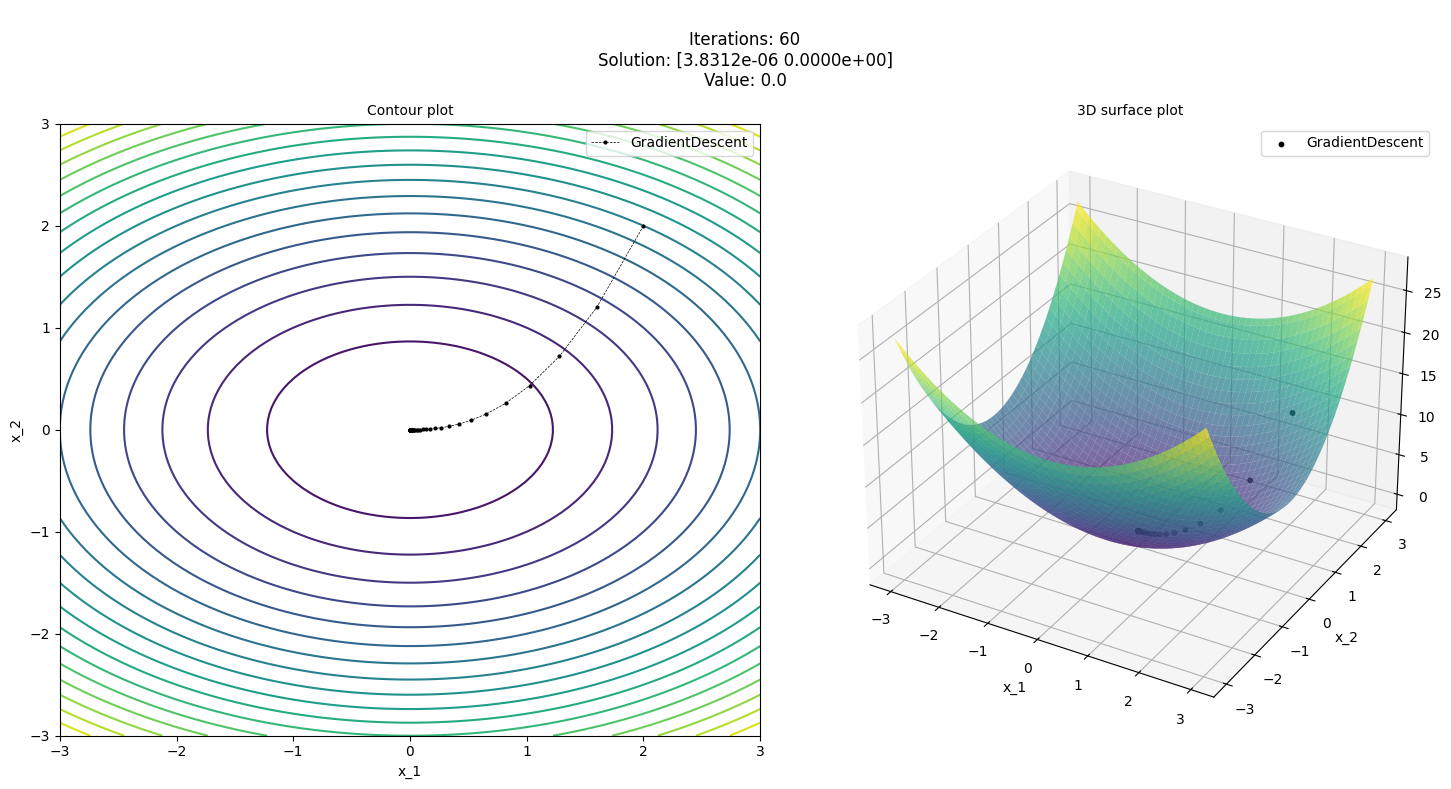

In [26]:
f = lambda x: test.quadratic(x, 1.0, 2.0)
grad = lambda x: test.quadratic_grad(x, 1.0, 2.0)

gd = GradientDescent(f, grad, lr=0.1)
gd.execute([2.0, 2.0], 100, 1e-6)
pltutils.plot_run(gd, np.linspace(-3, 3, 100), plot_3d=True)

### Gradient descent with momentum

In [7]:
class MomentumGradientDescent(NumericalAlgo):
    def __init__(self, function, grad, lr=0.1, beta=0.7):
        super().__init__(function)
        self.grad = grad
        self.lr = lr
        self.beta = beta

    def execute(self, x0, n_iter, epsilon):
        x = np.array(x0, dtype=float)
        self.result = [x.copy()]
        v = np.zeros_like(x)
        for _ in range(n_iter):
            v = self.beta * v + self.lr * self.grad(x)
            x_new = x - v
            self.result.append(x_new.copy())
            if np.linalg.norm(x_new - x) < epsilon:
                break
            x = x_new

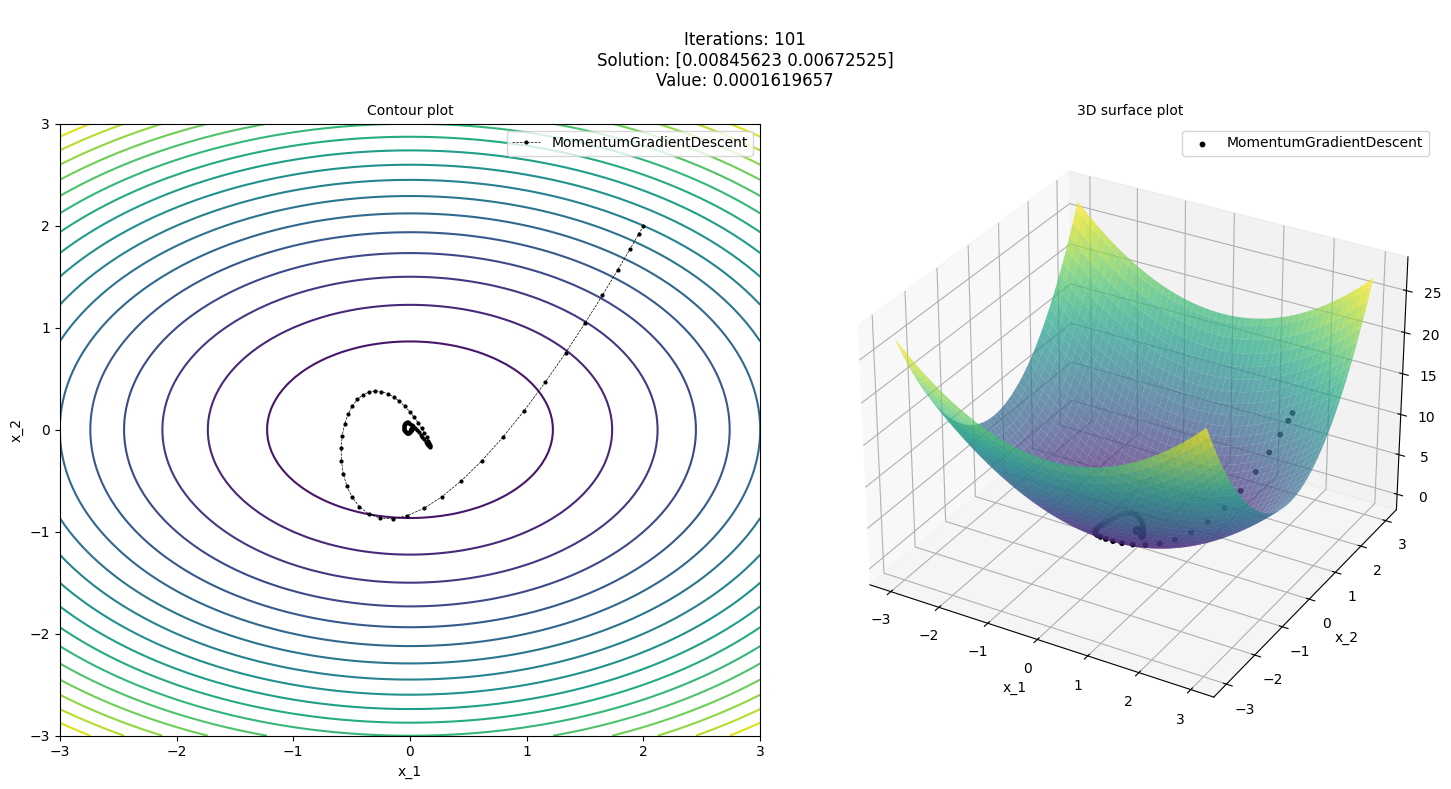

In [22]:
gd_momentum = MomentumGradientDescent(f, grad, lr=0.01, beta=0.9)
gd_momentum.execute([2.0, 2.0], 100, 1e-6)
pltutils.plot_run(gd_momentum, np.linspace(-3, 3, 100), plot_3d=True)

### RMSProp

In [9]:
class RMSProp(NumericalAlgo):
    def __init__(self, function, grad, lr=0.1, beta=0.9, epsilon_denom=1e-8):
        super().__init__(function)
        self.grad = grad
        self.lr = lr
        self.beta = beta
        self.epsilon_denom = epsilon_denom

    def execute(self, x0, n_iter, epsilon):
        x = np.array(x0, dtype=float)
        self.result = [x.copy()]
        s = np.zeros_like(x)
        for _ in range(n_iter):
            g = self.grad(x)
            s = self.beta * s + (1 - self.beta) * (g ** 2)
            x_new = x - self.lr * g / (np.sqrt(s) + self.epsilon_denom)
            self.result.append(x_new.copy())
            if np.linalg.norm(x_new - x) < epsilon:
                break
            x = x_new

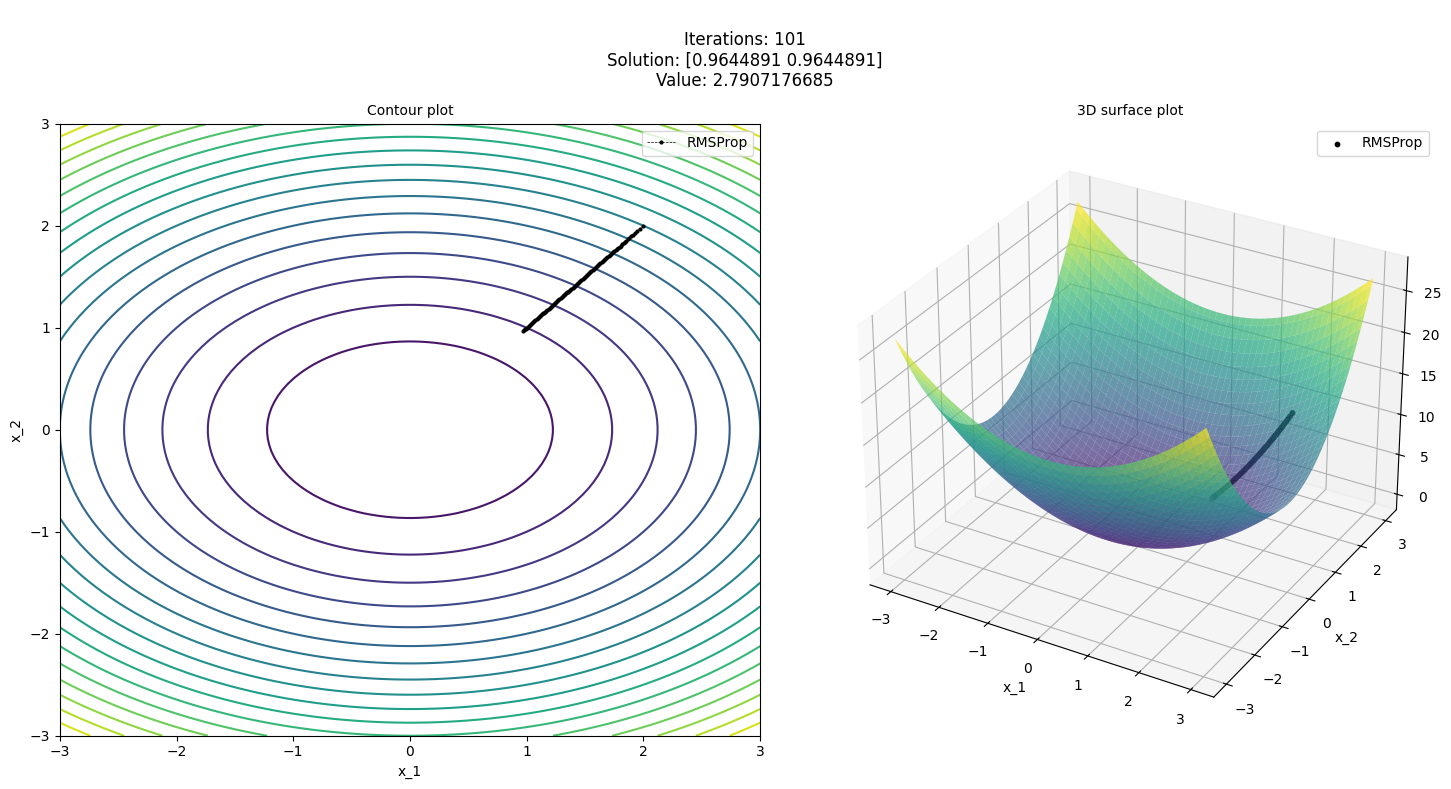

In [24]:
rmsprop = RMSProp(f, grad, lr=0.01, beta=0.9)
rmsprop.execute([2.0, 2.0], 100, 1e-6)
pltutils.plot_run(rmsprop, np.linspace(-3, 3, 100), plot_3d=True)

### ADAGRAD

In [11]:
class AdaGrad(NumericalAlgo):
    def __init__(self, function, grad, lr=0.5, epsilon_denom=1e-8):
        super().__init__(function)
        self.grad = grad
        self.lr = lr
        self.epsilon_denom = epsilon_denom

    def execute(self, x0, n_iter, epsilon):
        x = np.array(x0, dtype=float)
        self.result = [x.copy()]
        s = np.zeros_like(x)
        for _ in range(n_iter):
            g = self.grad(x)
            s += g ** 2
            x_new = x - self.lr * g / (np.sqrt(s) + self.epsilon_denom)
            self.result.append(x_new.copy())
            if np.linalg.norm(x_new - x) < epsilon:
                break
            x = x_new

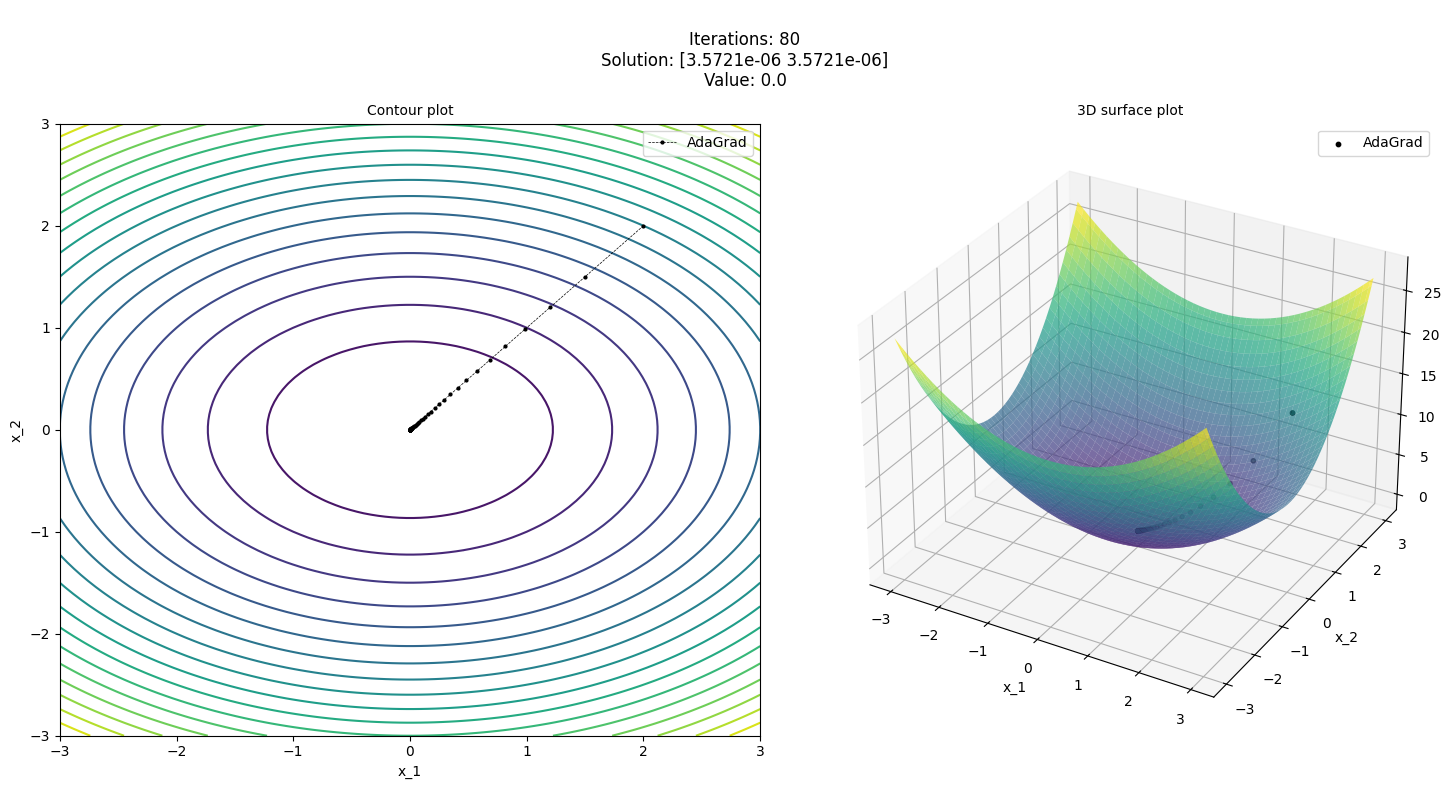

In [28]:
adagrad = AdaGrad(f, grad, lr=0.5)
adagrad.execute([2.0, 2.0], 100, 1e-6)
pltutils.plot_run(adagrad, np.linspace(-3, 3, 100), plot_3d=True)

### ADAM

In [13]:
class Adam(NumericalAlgo):
    def __init__(self, function, grad, lr=0.1, beta1=0.9, beta2=0.999, epsilon_denom=1e-8):
        super().__init__(function)
        self.grad = grad
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon_denom = epsilon_denom

    def execute(self, x0, n_iter, epsilon):
        x = np.array(x0, dtype=float)
        self.result = [x.copy()]
        m = np.zeros_like(x)
        v = np.zeros_like(x)
        for t in range(1, n_iter + 1):
            g = self.grad(x)
            m = self.beta1 * m + (1 - self.beta1) * g
            v = self.beta2 * v + (1 - self.beta2) * (g ** 2)

            m_hat = m / (1 - self.beta1 ** t)
            v_hat = v / (1 - self.beta2 ** t)

            x_new = x - self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon_denom)
            self.result.append(x_new.copy())
            if np.linalg.norm(x_new - x) < epsilon:
                break
            x = x_new

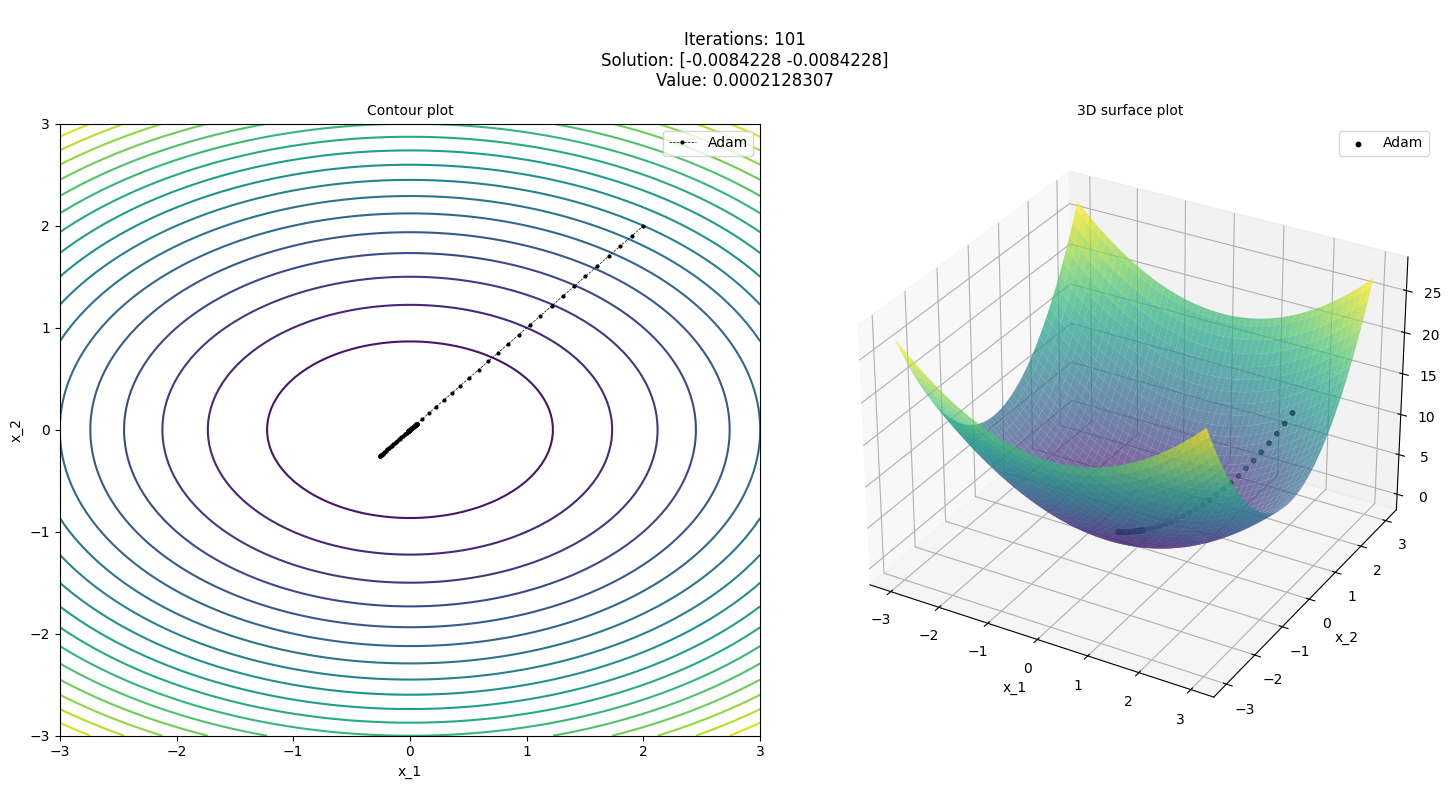

In [14]:
adam = Adam(f, grad, lr=0.1)
adam.execute([2.0, 2.0], 100, 1e-6)
pltutils.plot_run(adam, np.linspace(-3, 3, 100), plot_3d=True)

### Tasks

1. Find maximum of following function:

$$f(x,y)=x-xy+y-(x^2+y^2)$$

2. Compare different gradient methods using `plateau_function` and visualize them. Plot on interval $(-2,2) \times (-2,2)$ with $(1, 1)$ as starting point.